Imports

In [48]:
import cv2
import imutils
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from emnist import extract_training_samples

Loads an image from the provided path and converts it to grayscale.

In [49]:
image_path = 'images/img_1.png'

image = cv2.cvtColor(cv2.imread(image_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

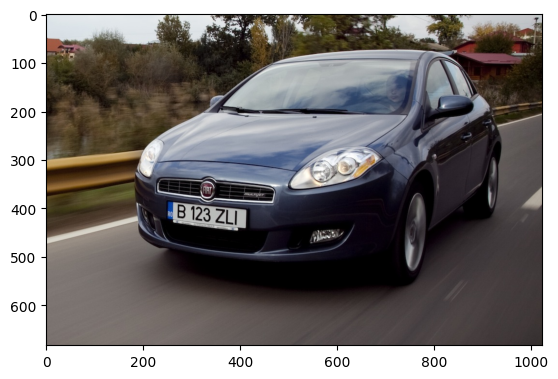

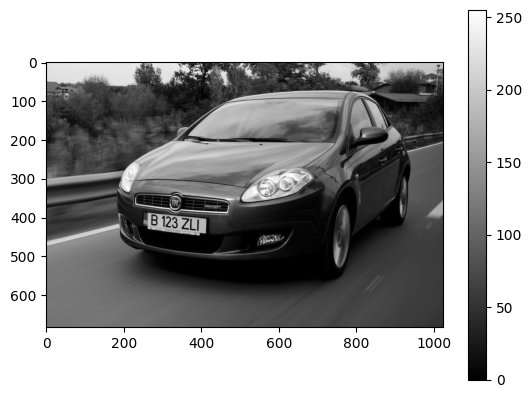

(<Figure size 640x480 with 2 Axes>,
 None)

In [50]:
plt.figure(), plt.imshow(image), plt.show(), plt.show()
plt.figure(), plt.imshow(gray_image, cmap='gray'), plt.colorbar(), plt.show()

Detects the license plate from the preprocessed grayscale image.
Uses edge detection and contour filtering to locate the plate.

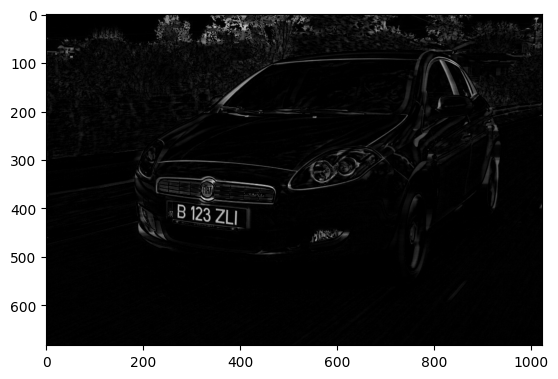

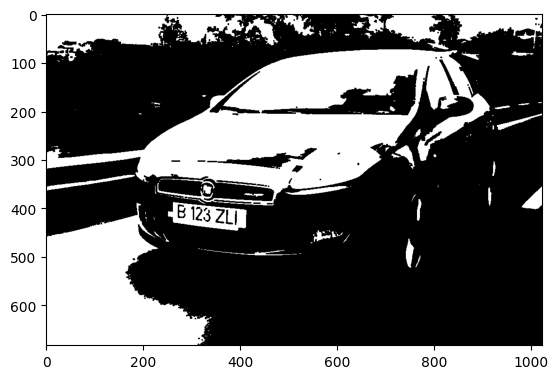

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [126]:
# Find contours in the binary image
rectKern = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(gray_image, cv2.MORPH_BLACKHAT, rectKern)
plt.figure(), plt.imshow(blackhat, cmap='gray'), plt.colorbar, plt.show()

plates = []

# next, find regions in the image that are light
squareKern = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
light = cv2.morphologyEx(gray_image, cv2.MORPH_CLOSE, squareKern)
light = cv2.threshold(light, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
plt.figure(), plt.imshow(light, cmap='gray'), plt.colorbar, plt.show()

            

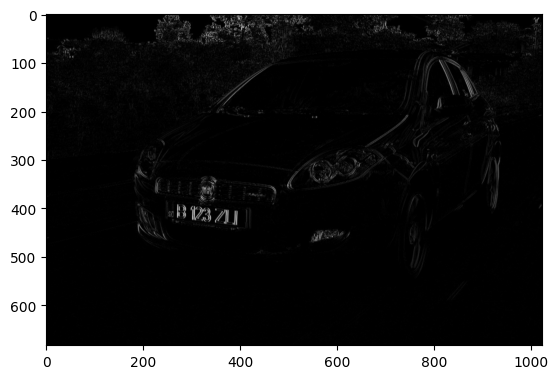

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [127]:
import numpy as np

# compute the Scharr gradient representation of the blackhat
# image in the x-direction and then scale the result back to
# the range [0, 255]
gradX = cv2.Sobel(blackhat, ddepth=cv2.CV_32F,
    dx=1, dy=0, ksize=-1)
gradX = np.absolute(gradX)
(minVal, maxVal) = (np.min(gradX), np.max(gradX))
gradX = 255 * ((gradX - minVal) / (maxVal - minVal))
gradX = gradX.astype("uint8")
plt.figure(), plt.imshow(gradX, cmap='gray'), plt.colorbar, plt.show()


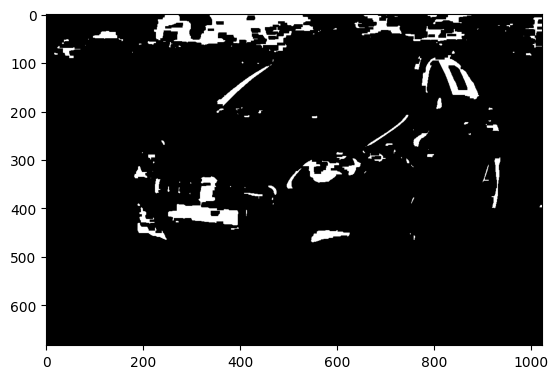

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [128]:
# blur the gradient representation, applying a closing
# operation, and threshold the image using Otsu's method
gradX = cv2.GaussianBlur(gradX, (5, 5), 0)
gradX = cv2.morphologyEx(gradX, cv2.MORPH_CLOSE, rectKern)
thresh = cv2.threshold(gradX, 0, 255,
    cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
plt.figure(), plt.imshow(thresh, cmap='gray'), plt.colorbar, plt.show()

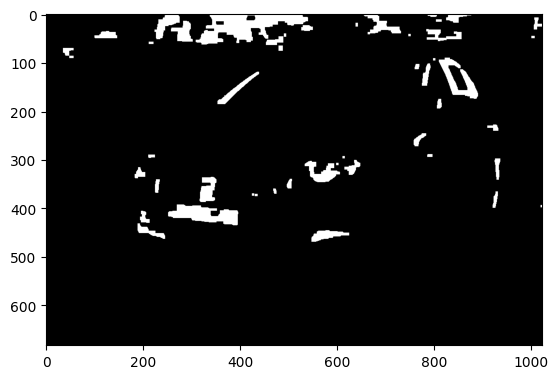

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [129]:
# perform a series of erosions and dilations to clean up the
# thresholded image
thresh = cv2.erode(thresh, None, iterations=2)
thresh = cv2.dilate(thresh, None, iterations=2)
plt.figure(), plt.imshow(thresh, cmap='gray'), plt.colorbar, plt.show()

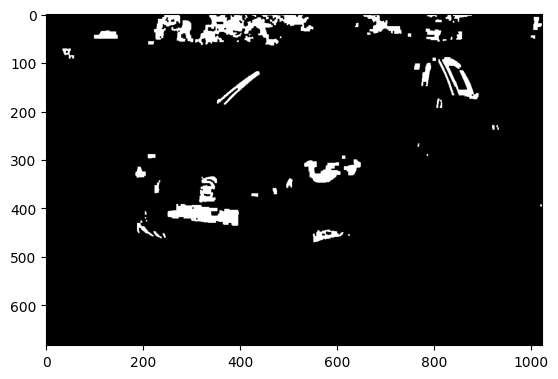

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [130]:
# take the bitwise AND between the threshold result and the
# light regions of the image
thresh = cv2.bitwise_and(thresh, thresh, mask=light)
thresh = cv2.dilate(thresh, None, iterations=2)
thresh = cv2.erode(thresh, None, iterations=1)
plt.figure(), plt.imshow(thresh, cmap='gray'), plt.colorbar, plt.show()

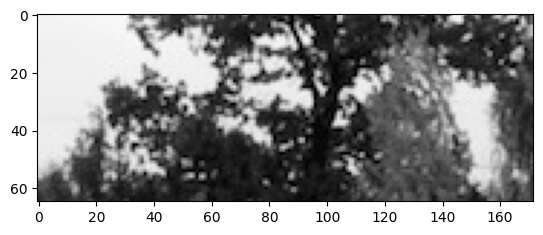

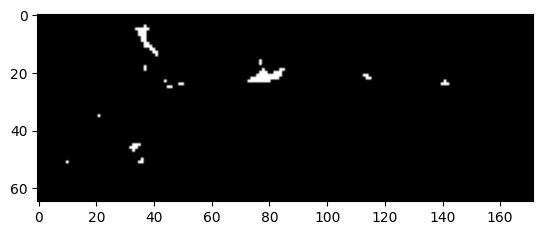

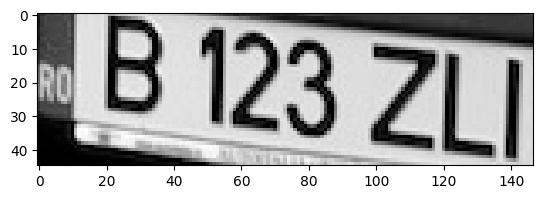

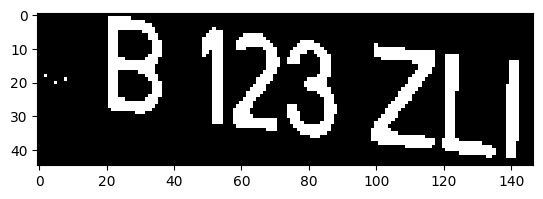

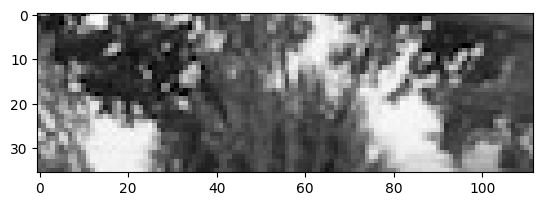

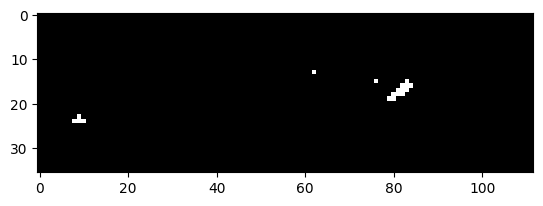

In [131]:
from skimage.segmentation import clear_border
import imutils
# find contours in the thresholded image and sort them by
# their size in descending order, keeping only the largest
# ones
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]

# initialize the license plate contour and ROI
lpCnt = None
roi = None
rois = []
# loop over the license plate candidate contours
for c in cnts:
    # compute the bounding box of the contour and then use
    # the bounding box to derive the aspect ratio
    (x, y, w, h) = cv2.boundingRect(c)
    ar = w / float(h)
    # check to see if the aspect ratio is rectangular
    if 2 <= ar <= 5:
        # store the license plate contour and extract the
        # license plate from the grayscale image and then
        # threshold it
        lpCnt = c
        licensePlate = gray_image[y:y + h, x:x + w]
        roi = cv2.threshold(licensePlate, 0, 255,
            cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
        
        # check to see if we should clear any foreground
        # pixels touching the border of the image
        # (which typically, not but always, indicates noise)
        roi = clear_border(roi)
        rois.append(roi)
        # display any debugging information and then break
        # from the loop early since we have found the license
        # plate region
        plt.figure(), plt.imshow(licensePlate, cmap='gray'), plt.colorbar, plt.show()
        plt.figure(), plt.imshow(roi, cmap='gray'), plt.colorbar, plt.show()
		# return a 2-tuple of the license plate ROI and the contour
		# associated with it

Segments individual characters from the detected license plate.
Uses thresholding and contour detection to isolate each character.

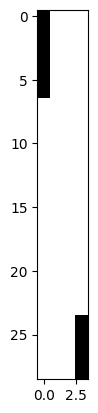

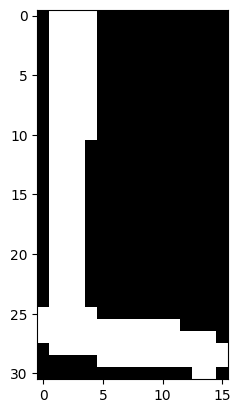

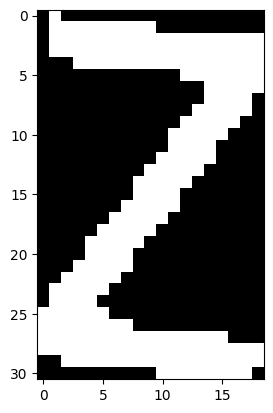

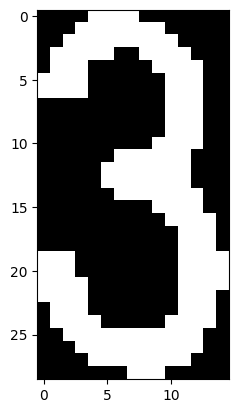

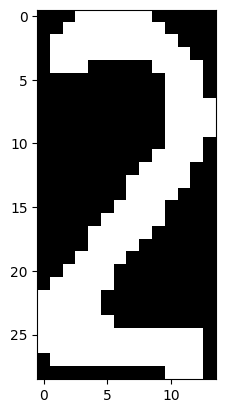

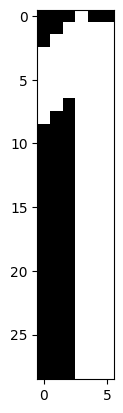

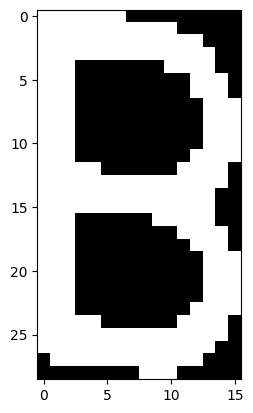

In [139]:
characters = []
for plate in rois:
    # Detect contours for each character in the license plate
    contours, _ = cv2.findContours(plate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Extract each character based on the bounding rectangle of its contour
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if 20 < h < 40:  # Ignore small contours (noise)
            char = plate[y:y + h, x:x + w]
            plt.figure(), plt.imshow(char, cmap='gray'), plt.colorbar, plt.show()
            characters.append(char)
characters = characters[1:7]

Trains an SVM classifier on the EMNIST dataset and returns the trained classifier.

In [60]:
# Load the EMNIST dataset (for both digits and letters)
X_emnist, y_emnist = extract_training_samples('balanced')

# Flatten the images and split into train/test sets
X_emnist = X_emnist.reshape((len(X_emnist), -1))
X_train, X_test, y_train, y_test = train_test_split(X_emnist, y_emnist, test_size=0.2, random_state=42)

# Train SVM classifier on EMNIST dataset
classifier = svm.SVC(gamma='scale')
classifier.fit(X_train, y_train) #dureaza 26m 9s

# Test the classifier on test data and print accuracy
y_pred = classifier.predict(X_test)
print(f"Accuracy on EMNIST test set: {accuracy_score(y_test, y_pred):.2f}")

Accuracy on EMNIST test set: 0.84


Classifies each character using the provided classifier.
Characters are resized and flattened before being passed to the classifier.

In [141]:
emnist_labels = [
    "0",  # Label 0
    "1",  # Label 1
    "2",  # Label 2
    "3",  # Label 3
    "4",  # Label 4
    "5",  # Label 5
    "6",  # Label 6
    "7",  # Label 7
    "8",  # Label 8
    "9",  # Label 9
    "A",  # Label 10
    "B",  # Label 11
    "C",  # Label 12 (C or c)
    "D",  # Label 13
    "E",  # Label 14
    "F",  # Label 15
    "G",  # Label 16
    "H",  # Label 17
    "I",  # Label 18 (I or i)
    "J",  # Label 19
    "K",  # Label 20
    "L",  # Label 21
    "M",  # Label 22
    "N",  # Label 23
    "O",  # Label 24 (O or o)
    "P",  # Label 25
    "Q",  # Label 26
    "R",  # Label 27
    "S",  # Label 28 (S or s)
    "T",  # Label 29
    "U",  # Label 30
    "V",  # Label 31
    "W",  # Label 32
    "X",  # Label 33 (X or x)
    "Y",  # Label 34
    "Z",  # Label 35 (Z or z)
    "a",  # Label 36
    "b",  # Label 37
    "d",  # Label 38
    "e",  # Label 39
    "f",  # Label 40
    "g",  # Label 41
    "h",  # Label 42
    "n",  # Label 43
    "q",  # Label 44
    "r",  # Label 45
    "t"   # Label 46
]

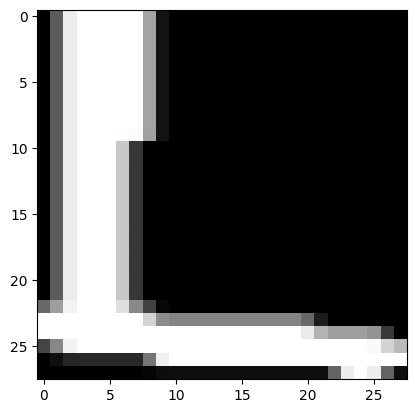

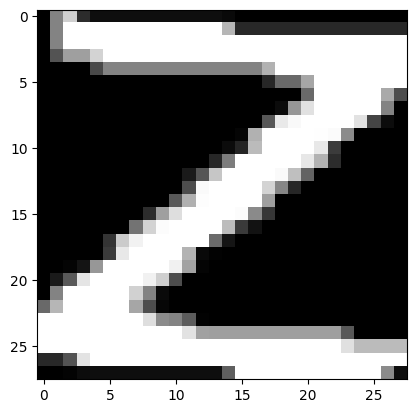

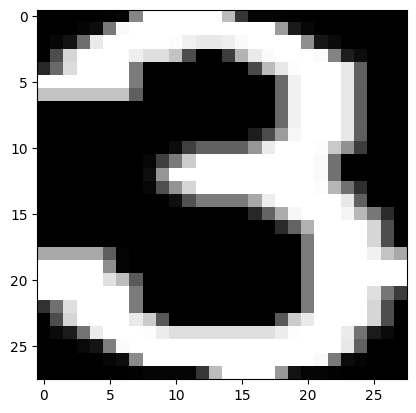

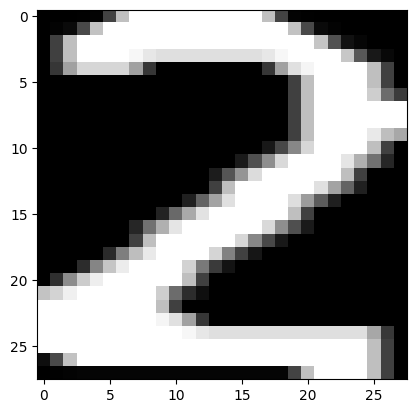

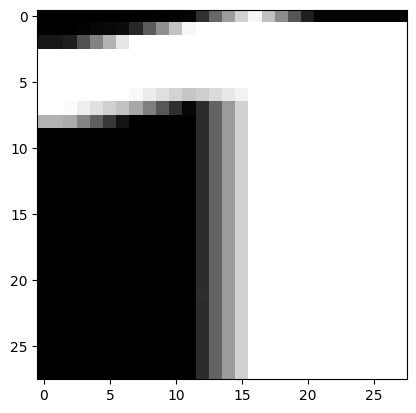

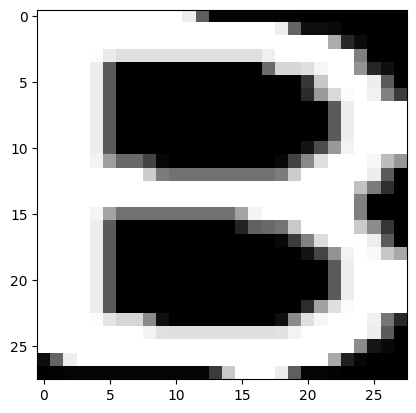

Recognized License Plate:  GBBBQQ


In [142]:
recognized_text = ""
for char in characters:
    # Resize each character to 28x28, similar to EMNIST digit size
    char_resized = cv2.resize(char, (28, 28))
    plt.figure(), plt.imshow(char_resized, cmap='gray'), plt.colorbar, plt.show()
    char_flatten = char_resized.flatten().reshape(1, -1)

    # Predict the character using the trained classifier
    recognized_char = classifier.predict(char_flatten)
    recognized_text += emnist_labels[recognized_char[0]]

if recognized_text != "":
    print("Recognized License Plate: ", recognized_text)
else:
    print("License plate could not be detected.")